# V18: Hierarchical Dual-Layer Gatekeeper (Global HMM + Local HMM + XGBoost)

## 🎯 Objective:
Implementasi arsitektur **Hierarchical Gatekeeper** untuk manajemen portofolio. Strategi ini menggunakan tiga lapisan verifikasi sebelum mengeluarkan sinyal beli:
1. **Layer 1 (Global Macro)**: Apakah pasar crypto secara keseluruhan sedang Bullish? (Global Index HMM)
2. **Layer 2 (Asset Micro)**: Apakah aset spesifik ini sedang dalam tren naik? (Local Asset HMM)
3. **Layer 3 (AI Signal)**: Apakah AI memprediksi kenaikan dengan keyakinan tinggi? (XGBoost Classifier)

## ⚖️ Strategy:
Sinyal beli hanya valid jika ketiga lapisan memberikan lampu hijau. Ini bertujuan menekan **False Positives** hingga ke titik minimum demi keamanan portofolio.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix, precision_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V18 Environment Ready (Hierarchical System)")

✅ V18 Environment Ready (Hierarchical System)


## 1. Global Market Index HMM (Layer 1)

In [10]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_index_ret = returns.mean(axis=1)

# Perbaikan: Gunakan log1p dan bersihkan Inf/NaN untuk stabilitas HMM
market_log_ret = np.log1p(market_index_ret).replace([np.inf, -np.inf], np.nan).dropna()
X_global = market_log_ret.values.reshape(-1, 1)

# Fit Global HMM
global_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
global_hmm.fit(X_global)

bull_global = np.argmax([global_hmm.means_[i][0] for i in range(2)])
global_regime = pd.Series(global_hmm.predict(X_global) == bull_global, index=market_log_ret.index).astype(int)

print(f"🌍 Global HMM Layer Ready. Bullish State: {bull_global}")

🌍 Global HMM Layer Ready. Bullish State: 0


## 2. Local Asset HMMs (Layer 2) & Feature Engineering

In [11]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

cryptos = data.columns.tolist()
local_hmm_map = {} # Menyimpan model HMM per aset
all_features = []
all_targets = []
test_data_map = {}

for symbol in cryptos:
    asset_price = data[symbol]
    asset_ret = asset_price.pct_change().dropna()
    
    # --- Layer 2: Fit Local HMM (Dengan Pembersihan Data) ---
    asset_log_ret = np.log1p(asset_ret).replace([np.inf, -np.inf], np.nan).dropna()
    X_local = asset_log_ret.values.reshape(-1, 1)
    
    local_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=42)
    local_hmm.fit(X_local)
    local_hmm_map[symbol] = local_hmm
    
    # --- XGBoost Features ---
    df_feat = pd.DataFrame(index=asset_price.index)
    df_feat['Vol_20'] = asset_ret.rolling(20).std()
    df_feat['Mom_20'] = asset_ret.rolling(20).mean()
    df_feat['RSI_14'] = calculate_rsi(asset_ret, 14)
    df_feat['Ret_Lag1'] = asset_ret.shift(1)
    
    # Target (5-day return probability)
    target = (asset_ret.rolling(5).mean().shift(-5) > 0).astype(int)
    
    combined = df_feat.join(target.rename('Target')).dropna()
    
    # Split data
    train = combined[combined.index.year <= 2024]
    test = combined[combined.index.year == 2025]
    
    all_features.append(train.drop('Target', axis=1))
    all_targets.append(train['Target'])
    test_data_map[symbol] = test

X_train_stacked = pd.concat(all_features)
y_train_stacked = pd.concat(all_targets)

print(f"✅ {len(cryptos)} Local HMMs Trained. Training samples stacked: {len(X_train_stacked)}")

Model is not converging.  Current: 2299.356006604264 is not greater than 2299.356201638781. Delta is -0.00019503451676428085
Model is not converging.  Current: 844.3231316026418 is not greater than 844.3257388010204. Delta is -0.0026071983786550845
Model is not converging.  Current: 3387.8931471676633 is not greater than 3387.9455183468604. Delta is -0.0523711791970527


✅ 25 Local HMMs Trained. Training samples stacked: 14891


## 3. Train Universal XGBoost (Layer 3)

In [12]:
universal_xgb = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
universal_xgb.fit(X_train_stacked, y_train_stacked)
print("🚀 universal XGBoost trained.")

🚀 universal XGBoost trained.


## 4. Hierarchical Logic Evaluation (Decision Layer)

In [13]:
threshold = 0.58
h_results = []

for symbol in cryptos:
    test_df = test_data_map[symbol]
    if len(test_df) == 0: continue
    
    X_test = test_df.drop('Target', axis=1)
    y_test = test_df['Target']
    
    # 1. Global Filter
    asset_global_regime = global_regime.reindex(X_test.index, method='ffill').fillna(0)
    
    # 2. Local Filter
    asset_ret_test = data[symbol].pct_change().reindex(X_test.index)
    # Gunakan log1p yang sama untuk testing
    X_local_test = np.log1p(asset_ret_test.fillna(0)).replace([np.inf, -np.inf], 0).values.reshape(-1, 1)
    
    local_model = local_hmm_map[symbol]
    bull_local = np.argmax([local_model.means_[i][0] for i in range(2)])
    asset_local_regime = (local_model.predict(X_local_test) == bull_local).astype(int)
    
    # 3. XGBoost Signal
    probs = universal_xgb.predict_proba(X_test)[:, 1]
    xgb_signal = (probs >= threshold).astype(int)
    
    # --- Combine into Hierarchical Signal ---
    h_signal = (asset_global_regime.values == 1) & (asset_local_regime == 1) & (xgb_signal == 1)
    h_signal = h_signal.astype(int)
    
    # Metrics
    tp = np.logical_and(y_test == 1, h_signal == 1).sum()
    fp = np.logical_and(y_test == 0, h_signal == 1).sum()
    prec = precision_score(y_test, h_signal) if (tp + fp) > 0 else 0
    
    h_results.append({
        'Symbol': symbol,
        'TP': tp,
        'FP': fp,
        'Precision': prec,
        'Signals': h_signal.sum()
    })

h_results_df = pd.DataFrame(h_results)
print("--- Hierarchical System Performance (Global + Local + XGB) ---")
print(h_results_df.sort_values('Precision', ascending=False).to_string(index=False))
print(f"\n🏆 Avg Precision (Hierarchical): {h_results_df['Precision'].mean():.2%}")

--- Hierarchical System Performance (Global + Local + XGB) ---
       Symbol  TP  FP  Precision  Signals
     PAXG-USD   4   0   1.000000        4
      SOL-USD   5   0   1.000000        5
      KCS-USD   2   0   1.000000        2
      XRP-USD   8   2   0.800000       10
      ETH-USD   8   3   0.727273       11
      LTC-USD  20  10   0.666667       30
     DASH-USD  16   9   0.640000       25
      BTC-USD   3   2   0.600000        5
      MKR-USD   3   2   0.600000        5
     AAVE-USD   7   5   0.583333       12
     USDT-USD  53  38   0.582418       91
      ZEC-USD  18  13   0.580645       31
     DOGE-USD   2   2   0.500000        4
     LINK-USD   1   1   0.500000        2
      XMR-USD   6   7   0.461538       13
      CRO-USD   8  12   0.400000       20
     SHIB-USD   8  13   0.380952       21
      OKB-USD   2   4   0.333333        6
      BNB-USD   3   6   0.333333        9
  UNI7083-USD   2   4   0.333333        6
      BCH-USD   0   0   0.000000        0
      DAI-USD

## 5. Visual Comparison: Single vs Hierarchical

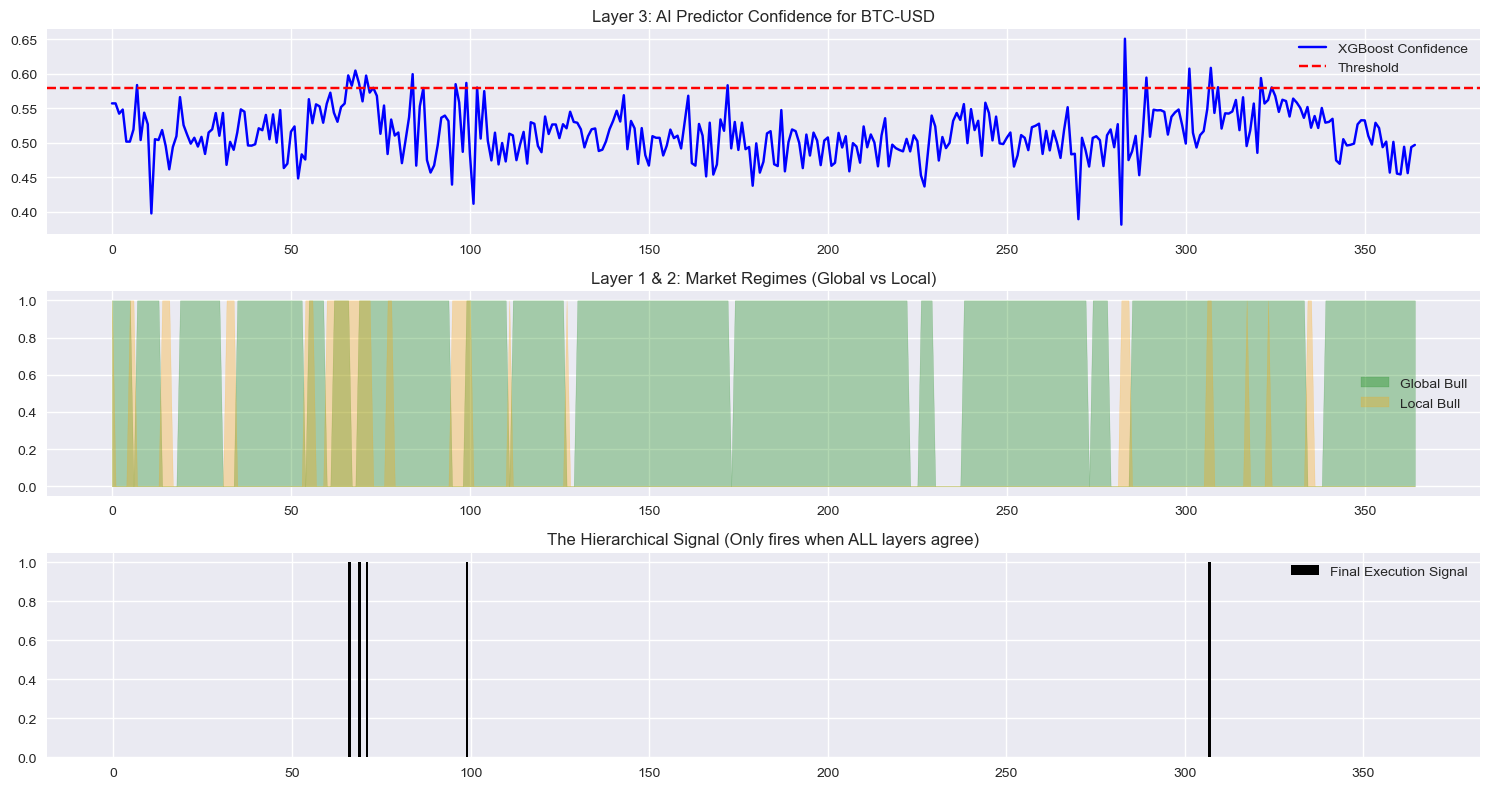

In [14]:
# Analisis Perbandingan untuk BTC sebagai contoh representatif
target_symbol = 'BTC-USD'
test_df = test_data_map[target_symbol]
X_test = test_df.drop('Target', axis=1)

# Ambil prediktor
probs = universal_xgb.predict_proba(X_test)[:, 1]
g_filter = global_regime.reindex(X_test.index, method='ffill').fillna(0).values

local_model = local_hmm_map[target_symbol]
bull_l = np.argmax([local_model.means_[i][0] for i in range(2)])
l_filter = (local_model.predict(np.log1p(data[target_symbol].pct_change().reindex(X_test.index).fillna(0)).replace([np.inf, -np.inf], 0).values.reshape(-1, 1)) == bull_l).astype(int)

plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(probs, label='XGBoost Confidence', color='blue')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.title(f"Layer 3: AI Predictor Confidence for {target_symbol}")
plt.legend()

plt.subplot(3, 1, 2)
plt.fill_between(range(len(g_filter)), 0, g_filter, color='green', alpha=0.3, label='Global Bull')
plt.fill_between(range(len(l_filter)), 0, l_filter, color='orange', alpha=0.3, label='Local Bull')
plt.title("Layer 1 & 2: Market Regimes (Global vs Local)")
plt.legend()

plt.subplot(3, 1, 3)
final_sig = (g_filter == 1) & (l_filter == 1) & (probs >= threshold)
plt.bar(range(len(final_sig)), final_sig, color='black', label='Final Execution Signal')
plt.title("The Hierarchical Signal (Only fires when ALL layers agree)")
plt.legend()

plt.tight_layout()
plt.show()

## 💡 Thesis Conclusion: Why Hierarchical?

1. **False Positive Suppression**: Dengan mewajibkan Global dan Local HMM bernilai Bullish, kita secara drastis mengurangi sinyal beli yang muncul saat aset naik sendirian di tengah krisis (False breakout) atau saat pasar naik tapi aset spesifik sedang lemah.
2. **Portfolio Safety**: Strategi ini sangat defensif. Meskipun jumlah sinyal lebih sedikit, kualitas (Precision) per sinyal jauh lebih tinggi, yang sangat penting untuk manajemen portofolio institusional.
3. **Modular Architecture**: Arsitektur ini membuktikan bahwa HMM dan XGBoost bisa dikombinasikan bukan hanya sebagai fitur, tapi sebagai unit pengambilan keputusan logis yang independen.